# Learning to Implement Denoising Diffusion Probabilistic Models

In [1]:
from collections.abc import Callable
from copy import deepcopy
from IPython.display import HTML
import matplotlib
import matplotlib.animation as animation
import math
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as parametrize
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm
from typing import List, Tuple, Dict, Iterable

import sys
sys.path.append("/mnt/data/projects/scmultimodal/code")
from plot_utils import set_plot_style

In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = pathlib.Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/diffusion"
SAMPLE_DIR = DATA_DIR / "samples/diffusion"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

In [3]:
"""
coordinates = [
    [[x,y] for x in np.linspace(*(-3, 3), 1000)]
    for y in np.linspace(*(-3, 3), 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))


def animate(i):
    ax.cla()
    im = ax.imshow(
        prob, extent=[-3, 3, -3, 3], origin='lower', cmap='YlOrRd')
    ax.scatter(
        samples_all[i, :, 0], samples_all[i, :, 1], alpha=0.7, color="black")
    ax.set_xlim((-2.2, 2.2))
    ax.set_ylim((-2.2, 2.2))
    ax.set_aspect('equal')
    ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
    ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

    return fig

ani = animation.FuncAnimation(fig, animate, frames=100)

display(ani)
"""

'\ncoordinates = [\n    [[x,y] for x in np.linspace(*(-3, 3), 1000)]\n    for y in np.linspace(*(-3, 3), 1000)\n]\nprob = torch.exp(toy().log_prob(torch.tensor(coordinates)))\n\nfig, ax = plt.subplots(1, 1, figsize=(12, 7))\n\n\ndef animate(i):\n    ax.cla()\n    im = ax.imshow(\n        prob, extent=[-3, 3, -3, 3], origin=\'lower\', cmap=\'YlOrRd\')\n    ax.scatter(\n        samples_all[i, :, 0], samples_all[i, :, 1], alpha=0.7, color="black")\n    ax.set_xlim((-2.2, 2.2))\n    ax.set_ylim((-2.2, 2.2))\n    ax.set_aspect(\'equal\')\n    ax.set_xlabel("$x_1$-Coordinate", labelpad=20)\n    ax.set_ylabel("$x_2$-Coordinate", labelpad=20)\n\n    return fig\n\nani = animation.FuncAnimation(fig, animate, frames=100)\n\ndisplay(ani)\n'

# 0. Prerequisites

## 0.1 Data

### 0.1.1 Toy Distributions

In [4]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution


class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.1.2 MNIST

In [5]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x + torch.rand(x.shape)/255),
            transforms.Lambda(lambda x: (x-0.5)*2.0),
        ])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x + torch.rand(x.shape)/255),
            transforms.Lambda(lambda x: (x-0.5)*2.0),
        ])
    ),
    batch_size=batch_size, shuffle=True
)

### 0.2 My Own Basic NN Components

In [6]:
class DummyLayer(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__()
    
    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x

### 0.2.1 Basic MLP

In [7]:
class FCLayer(nn.Module):
    """
    WIP: add dropout
    """
    def __init__(
            self, in_feats: int, out_feats: int, use_batchnorm: bool=True,
            act_fun: nn.modules.activation=nn.ReLU
        ) -> None:
        super().__init__()

        modules = [nn.Linear(in_feats, out_feats)]
        if use_batchnorm:
            modules.append(nn.BatchNorm1d(out_feats))
        if act_fun is not None:
            modules.append(act_fun())
        
        self.fc_layer = nn.Sequential(*modules)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc_layer(x)

class MLP(nn.Module):
    """
    WIP: add dropout
    """
    def __init__(
            self, n_feats: int, out_size: int, 
            hidden_sizes: None|int|list[int]=None,
            act_funs: list[nn.Module]|nn.Module=nn.ReLU, flatten=False
        ) -> None:
        super().__init__()

        if hidden_sizes:
            if isinstance(hidden_sizes, int):
                hidden_sizes = [hidden_sizes]
            # parameterize the number of hidden layers and nodes
            layer_sizes = [n_feats] + hidden_sizes + [out_size]
            n_layers = len(layer_sizes) - 1
            in_layer_sizes = layer_sizes[0:n_layers]
            out_layer_sizes = layer_sizes[1:n_layers + 1]

            # parameterize activation functions
            if not isinstance(act_funs, list):
                act_funs = [act_funs]*n_layers

            fc_block_list = [
                FCLayer(n_in, n_out, use_batchnorm=False, act_fun=a_fun)
                for n_in, n_out, a_fun
                in zip(in_layer_sizes, out_layer_sizes, act_funs)
            ]
        else:
            fc_block_list = [FCLayer(n_feats, out_size, act_fun=act_funs)]
        
        if isinstance(flatten, bool) and flatten == True:
            fc_block_list.insert(0, nn.Flatten())
        elif not isinstance(flatten, bool):
            fc_block_list.append(nn.Unflatten(-1, flatten))
        
        self.network = nn.Sequential(*fc_block_list)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

### 0.2.2 Convolutional Layers

In [8]:
class Conv2DLayer(nn.Module):
    def __init__(
        self, in_chans: int, out_chans: int, conv_kernel_size: int,
        conv_pad_size: int, conv_stride_size: int=1, pool: None|str="max",
        pool_kernel_size: None|int=None, pool_stride: None|int=None,
        pool_padding: None|int=None,
        skip: bool=False, use_batchnorm: bool=False, act_fun=nn.ReLU,
        act_fun_pos: str="after_pool"
    ) -> None:
        super().__init__()

        modules = []
        modules.append(nn.Conv2d(
            in_chans, out_chans, kernel_size=conv_kernel_size,
            padding=conv_pad_size, stride=conv_stride_size
        ))

        if act_fun is not None and act_fun_pos == "after_conv":
            modules.append(act_fun())

        if pool:
            if pool == "max":
                modules.append(nn.MaxPool2d(
                    pool_kernel_size, stride=pool_stride, padding=pool_padding))
            elif pool == "mean":
                modules.append(nn.AvgPool2d(
                    pool_kernel_size, stride=pool_stride, padding=pool_padding))
        
        if use_batchnorm:
            modules.append(nn.BatchNorm2d(out_chans))

        if act_fun is not None and act_fun_pos == "after_pool":
            modules.append(act_fun())
        
        self.conv2d_layer = nn.Sequential(*modules)

        self.skip_flag = skip
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_out = self.conv2d_layer(x)
        if self.skip_flag:
            return x + x_out
        else:
            return x_out

class TransposeConv2DLayer(nn.Module):
    def __init__(
        self, in_chans: int, out_chans: int, kernel_size: int, in_pad_size: int,
        out_pad_size: int, stride_size: int, use_batchnorm: bool=False,
        act_fun=nn.ReLU
    ) -> None:
        super().__init__()
        
        modules = []
        modules.append(nn.ConvTranspose2d(
            in_chans, out_chans, kernel_size=kernel_size, stride=stride_size,
            padding=in_pad_size, output_padding=out_pad_size
        ))

        if use_batchnorm:
            modules.append(nn.BatchNorm2d(out_chans))
        if act_fun is not None:
            modules.append(act_fun())
        
        self.tconv2d_layer = nn.Sequential(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.tconv2d_layer(x)

class UNet(nn.Module):
    """
    TO-DO: Add shape checks for intermediate steps too
    """
    def __init__(
        self, n_feats: int, n_channels: int, hidden_channels: List[int],
        # convolution hyperparameters
        conv_kernel_sizes: List[int], conv_stride_sizes: List[int],
        conv_paddings: List[int], pool_kernel_sizes: List[int],
        pool_stride_sizes: List[int], pool_padding_sizes: List[int],
        # transpose convolution hyperparameters
        tconv_kernel_sizes: List[int], tconv_stride_sizes: List[int],
        tconv_in_paddings: List[int], tconv_out_paddings: List[int],
        pool: str="max",
        act_fun: torch.nn.modules.activation=nn.LogSigmoid
    ) -> None:
        assert (
            len(hidden_channels) == len(conv_kernel_sizes)
                == len(conv_stride_sizes) == len(conv_paddings)
                == len(pool_kernel_sizes) == len(pool_stride_sizes)
                == len(pool_padding_sizes)
        )
        assert (
            len(hidden_channels) == len(tconv_kernel_sizes)
            == len(tconv_stride_sizes) == len(tconv_in_paddings)
            == len(tconv_out_paddings)
        )
        super().__init__()

        self.n_layers = len(hidden_channels)
        convs = []
        pools = []
        hidden_channels = [n_channels] + hidden_channels
        in_channels = hidden_channels[0:-1]
        out_channels = hidden_channels[1:]
        n_feats_prime = n_feats
        for i_c, o_c, c_k, c_s, c_p, p_k, p_s, p_p in zip(
            in_channels, out_channels,
            conv_kernel_sizes, conv_stride_sizes, conv_paddings,
            pool_kernel_sizes, pool_stride_sizes, pool_padding_sizes,
        ):
            convs.append(Conv2DLayer(
                i_c, o_c, c_k, c_p, c_s, pool=None, act_fun=act_fun,
                act_fun_pos="after_conv"
            ))
            n_feats_prime = self.get_conv_pool_out_size(
                n_feats_prime, c_k, c_p, c_s)
            if p_k > 0:
                if pool == "max":
                    pools.append(nn.MaxPool2d(p_k, p_s, padding=p_p))
                elif pool == "avg":
                    pools.append(nn.AvgPool2d(p_k, p_s, padding=p_p))
                n_feats_prime = self.get_conv_pool_out_size(
                    n_feats_prime, p_k, p_p, p_s)
            else:
                pools.append(DummyLayer())
        
        tconvs = []
        for j, (o_c, i_c, t_k, t_s, i_p, o_p) in enumerate(zip(
            reversed(out_channels), reversed(in_channels),
            tconv_kernel_sizes, tconv_stride_sizes,
            tconv_in_paddings, tconv_out_paddings
        )):
            o_c = o_c*2 if j > 0 else o_c
            act_fun = act_fun if j < len(out_channels) - 1 else None
            tconvs.append(TransposeConv2DLayer(
                o_c, i_c, t_k, i_p, o_p, t_s, act_fun=act_fun
            ))
            n_feats_prime = self.get_tconv_out_size(
                n_feats_prime, t_k, i_p, o_p, t_s)
        
        self.convs = nn.ModuleList(convs)
        self.pools = nn.ModuleList(pools)
        self.tconvs = nn.ModuleList(tconvs)

        assert n_feats == n_feats_prime, (
            "Shape Error: Expected output shape to be the same as input "
            f"shape {n_feats} but got {n_feats_prime} instead"
        )

    def forward(self, x: torch.Tensor, cat_dim: int=1) -> torch.Tensor:
        c_xs = []
        for i, (conv, pool) in enumerate(zip(self.convs, self.pools)):
            x = conv(x)
            if i < self.n_layers - 1:
                # (B, C_in, H_in, W_in) -> (B, C_out, H_out, W_out)
                c_xs.append(x)
                x = pool(x)
        
        for j, tconv in enumerate(self.tconvs):
            if j > 0:
                # (B, 2*C_out, H_out, W_out) -> (B, C_in, H_in, W_in)
                x = torch.cat((x, c_xs[-j]), dim=cat_dim)
            x = tconv(x)
        
        return x
    
    @staticmethod
    def get_conv_pool_out_size(w: int, k: int, p: int, s: int) -> int:
        """
        w: input size
        k: kernel size
        p: padding
        s: stride
        """
        w_prime = (w - k + 2*p)//s + 1
        return w_prime

    @staticmethod
    def get_tconv_out_size(
        w_prime: int, k: int, i_p: int, o_p: int, s: int) -> int:
        """
        w_prime: output_size
        k: kernel size
        i_p: input padding
        o_p: output padding
        s: stride
        """
        w = (w_prime - 1)*s + k - 2*i_p + o_p
        return w

# 1. Diffusion Implementations

## 1.1 Basic Components

### 1.1.1 Embeddings

In [9]:
class SinusoidalPE(nn.Module):
    """
    Implementation taken from
    https://medium.com/@hirok4/understanding-transformer-sinusoidal-position-embedding-7cbaaf3b9f6a
    """
    def __init__(self, embedding_dim: int, timesteps: int) -> None:
        super().__init__()

        time_axis = torch.arange(timesteps).view(timesteps, 1)
        emb_axis = torch.arange(embedding_dim).view(1, embedding_dim)

        angle_rates = 1 / torch.pow(10000, (2 * (emb_axis // 2)) / embedding_dim)
        angle_rads = time_axis * angle_rates

        pos_enc = torch.zeros_like(angle_rads)
        pos_enc[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pos_enc[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        self.pos_enc = nn.Parameter(pos_enc, requires_grad=False)
    
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return self.pos_enc[t]

class ClassEmbedding(nn.Module):
    def __init__(
        self, embedding_dim: int, n_classes: int
    ) -> None:
        super().__init__()

        self.enc = nn.Parameter(torch.randn(n_classes, embedding_dim)*1e-2)
    
    def forward(
        self, y: torch.Tensor|None=None) -> torch.Tensor:
        if y is not None:
            # if some classes are missing (e.g. for unconditional training
            # with dropout)
            if (y < 0).any():
                m = (y < 0).float().view(-1, 1, 1)
                c = (
                    (1 - m) * self.enc[y]
                        + m * self.enc.mean(dim=0).unsqueeze(0)
                )
            else:
                c = self.enc[y]
        else:
            c = self.enc.mean(dim=0).unsqueeze(0)
        
        return c

### 1.1.2 Conditioned/Modulatable Networks

In [10]:
class FiLMedNetwork(nn.Module):
    def __init__(
        self, network: nn.Module|nn.Sequential,
        embedding: nn.Module|nn.Sequential, embedding_dim: int,
        feature_dim: int, act_fun: nn.Module|None=nn.ReLU
    ) -> None:
        super().__init__()

        self.emb = embedding
        self.net = network
        self.film = nn.Linear(embedding_dim, 2*feature_dim)
        if act_fun is not None:
            self.act_fun = act_fun()
        else:
            self.act_fun = None
    
    def forward(
        self, x: torch.Tensor, *conditions: torch.Tensor) -> torch.Tensor:
        c = self._get_embedding(*conditions)

        # 2 * (1/batch_size, hidden_channels)
        gamma, beta = torch.chunk(self.film(c), 2, dim=-1)
        if x.dim() == 4:
            # 2 * (1/batch_size, hidden_channels, height, width)
            gamma = gamma[:, :, None, None]
            beta = beta[:, :, None, None]
        else:
            pass
        # stabilize in case gamma is near 0
        gamma = gamma + 1.0

        x = self.net(x)
        x = x*gamma + beta
        if self.act_fun is not None:
            x = self.act_fun(x)
        
        return x

    def _get_embedding(self, c: torch.Tensor) -> torch.Tensor:
        return self.emb(c)

class FiLMHybrid(FiLMedNetwork):
    """
    Rework class a bit regarding embedding dim's and so on.
    """
    def __init__(
        self, network: nn.Module|nn.Sequential,
        continuous_embedding: nn.Module|nn.Sequential,
        class_embedding: nn.Module|nn.Sequential, embedding_dim_1: int,
        embedding_dim_2: int, feature_dim: int, act_fun: nn.Module|None=nn.ReLU
    ) -> None:
        super().__init__(
            network, continuous_embedding, embedding_dim_1, feature_dim,
            act_fun=act_fun
        )

        self.cont_emb = continuous_embedding
        self.class_emb = class_embedding
        self.mod_map = nn.Linear(
            embedding_dim_1 + embedding_dim_2, embedding_dim_1)
    
    def _get_embedding(
        self, t: torch.Tensor, y: torch.Tensor|None=None, cat_dim: int=1
    ) -> torch.Tensor:
        cont_emb, class_emb = self.cont_emb(t), self.class_emb(y)
        if class_emb.size(0) != cont_emb.size(0):
            class_emb = class_emb.expand((cont_emb.size(0), class_emb.size(1)))
        c = torch.cat([cont_emb, class_emb], dim=cat_dim)
        return self.mod_map(c)

class MLPTimeDependent(MLP):
    """
    TO-DO: Find a better solution than to overwrite the last layer again...
    """
    def __init__(
        self, n_timesteps: int, embedding_dim: int, *args,
        mlp_act_funs: List[nn.Module|None]|nn.Module|None=nn.ReLU,
        film_act_fun: nn.Module|None=nn.ReLU,
        **kwargs
    ):
        super().__init__(*args, act_funs=mlp_act_funs, **kwargs)

        new_networks = []
        for _, l_params in self.network.named_children():
            for _, s_params in l_params.named_children():
                for _, i_params in s_params.named_children():
                    if "linear" in str(type(i_params)):
                        feature_dim = i_params.out_features
                new_networks.append(FiLMedNetwork(
                    deepcopy(s_params), SinusoidalPE(
                        embedding_dim, n_timesteps), embedding_dim,
                    feature_dim, act_fun=film_act_fun
                ))
        # make sure the old network is not output-clipped by an activation
        # function
        new_networks[-1] = FiLMedNetwork(
            deepcopy(s_params), SinusoidalPE(
                embedding_dim, n_timesteps), embedding_dim,
            feature_dim, act_fun=None
        )
        
        self.network = nn.ModuleList(new_networks)
    
    def forward(self, x: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        for net in self.network:
            x = net(x, t)
        return x

class UNetTimeDependent(UNet):
    def __init__(
        self, n_timesteps: int, embedding_dim: int, *args,
        unet_act_fun: nn.Module|None=nn.ReLU,
        film_act_fun: nn.Module|None=nn.ReLU,
        **kwargs
    ) -> None:
        super().__init__(*args, act_fun=unet_act_fun, **kwargs)

        new_convs = []
        for conv in self.convs:
            for _, l_params in conv.named_children():
                for _, s_params in l_params.named_children():
                    if "conv" in str(type(s_params)):
                        new_convs.append(FiLMedNetwork(
                            deepcopy(conv), SinusoidalPE(
                                embedding_dim, n_timesteps),
                            embedding_dim, s_params.out_channels,
                            act_fun=film_act_fun
                        ).to(DEVICE))
        self.convs = nn.ModuleList(new_convs)

        new_tconvs = []
        for j, tconv in enumerate(self.tconvs):
            # make sure the old network is not output-clipped by an activation
            # function
            f_act_fun = film_act_fun if j < len(self.tconvs) - 1 else None
            for _, l_params in tconv.named_children():
                for _, s_params in l_params.named_children():
                    if "Transpose" in str(type(s_params)):
                        new_tconvs.append(FiLMedNetwork(
                            deepcopy(tconv), SinusoidalPE(
                                embedding_dim, n_timesteps),
                            embedding_dim, s_params.out_channels,
                            act_fun=f_act_fun
                        ).to(DEVICE))
        self.tconvs = nn.ModuleList(new_tconvs)

    def forward(
        self, x: torch.Tensor, t: torch.Tensor, cat_dim: int=1, **kwargs
    ) -> torch.Tensor:
        c_xs = []
        for i, (conv, pool) in enumerate(zip(self.convs, self.pools)):
            x = conv(x, t)
            if i < self.n_layers - 1:
                # (B, C_in, H_in, W_in) -> (B, C_out, H_out, W_out)
                c_xs.append(x)
                x = pool(x)
        
        for j, tconv in enumerate(self.tconvs):
            if j > 0:
                # (B, 2*C_out, H_out, W_out) -> (B, C_in, H_in, W_in)
                x = torch.cat((x, c_xs[-j]), dim=cat_dim)
            x = tconv(x, t)
        
        return x

class UNetTimeClassDependent(UNet):
    def __init__(
        self, n_timesteps: int, time_emb_dim: int, class_emb_dim,
        n_classes: int, *args,
        unet_act_fun: nn.Module|None=nn.ReLU,
        film_act_fun: nn.Module|None=nn.ReLU,
        **kwargs
    ) -> None:
        super().__init__(*args, act_fun=unet_act_fun, **kwargs)

        new_convs = []
        for conv in self.convs:
            for _, l_params in conv.named_children():
                for _, s_params in l_params.named_children():
                    if "conv" in str(type(s_params)):
                        new_convs.append(FiLMHybrid(
                            deepcopy(conv), SinusoidalPE(
                                time_emb_dim, n_timesteps),
                            ClassEmbedding(class_emb_dim, n_classes),
                            time_emb_dim, class_emb_dim, s_params.out_channels,
                            act_fun=film_act_fun
                        ).to(DEVICE))
        self.convs = nn.ModuleList(new_convs)

        new_tconvs = []
        for j, tconv in enumerate(self.tconvs):
            # make sure the old network is not output-clipped by an activation
            # function
            f_act_fun = film_act_fun if j < len(self.tconvs) - 1 else None
            for _, l_params in tconv.named_children():
                for _, s_params in l_params.named_children():
                    if "Transpose" in str(type(s_params)):
                        new_tconvs.append(FiLMHybrid(
                            deepcopy(tconv), SinusoidalPE(
                                time_emb_dim, n_timesteps),
                            ClassEmbedding(class_emb_dim, n_classes),
                            time_emb_dim, class_emb_dim, s_params.out_channels,
                            act_fun=f_act_fun
                        ).to(DEVICE))
        self.tconvs = nn.ModuleList(new_tconvs)

    def forward(
        self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor|None=None,
        cat_dim: int=1
    ) -> torch.Tensor:
        c_xs = []
        for i, (conv, pool) in enumerate(zip(self.convs, self.pools)):
            x = conv(x, t, y)
            if i < self.n_layers - 1:
                # (B, C_in, H_in, W_in) -> (B, C_out, H_out, W_out)
                c_xs.append(x)
                x = pool(x)
        
        for j, tconv in enumerate(self.tconvs):
            if j > 0:
                # (B, 2*C_out, H_out, W_out) -> (B, C_in, H_in, W_in)
                x = torch.cat((x, c_xs[-j]), dim=cat_dim)
            x = tconv(x, t, y)
        
        return x

## 1.2 Core Components

### 1.2.1 Base Distributions

In [11]:
class GaussianBase(nn.Module):
    normalization_constant = 0.5 * torch.log(
        torch.Tensor([2 * torch.pi]).to(DEVICE))
    def __init__(self, dimensionality: Tuple) -> None:
        super().__init__()

        self.dim = dimensionality
        self.mean = nn.Parameter(torch.zeros(*self.dim), requires_grad=False)
        self.std = nn.Parameter(torch.ones(*self.dim), requires_grad=False)
    
    def forward(self) -> td.Distribution:
        return td.Independent(td.Normal(self.mean, self.std), len(self.dim))

### 1.2.2 Noise Schedule

In [12]:
class NoiseSchedule(nn.Module):
    def __init__(self, n_timesteps: int) -> None:
        super().__init__()
        
        self.T = n_timesteps 
    
    def forward(
        self, x: torch.Tensor, epsilon: torch.Tensor, t: torch.Tensor
    ) -> torch.Tensor:
        return NotImplementedError
    
    def _broadcast(self, v: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """
        Broadcast some parameter to data shape.
        """
        return v.view(v.size(0), *([1]*(x.dim() - 1)))
    
    def _extract(
        self, v: torch.Tensor, t: torch.Tensor, x: torch.Tensor
    ) -> torch.Tensor:
        """
        Extract correct dimensions from time-dependent parameter and broadcast
        to data shape.
        """
        v = v.gather(0, t)
        return self._broadcast(v, x)

class GaussianSchedule(NoiseSchedule):
    def forward(
        self, x: torch.Tensor, epsilon: torch.Tensor, t: torch.Tensor
    ) -> torch.Tensor:
        alpha, sigma = self._get_alpha_sigma(t, x)
        z = alpha*x + sigma*epsilon
        
        return z
    
    def loss_coef(self, t: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError
    
    def _get_alpha_sigma(
        self, t: torch.Tensor, x:torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        raise NotImplementedError

class ConstantLinearSchedule(GaussianSchedule):
    def __init__(
        self, n_timesteps: int, beta: Tuple[float, float]=(1e-4, 2e-2)
    ) -> None:
        super().__init__(n_timesteps)
        
        self.beta = nn.Parameter(
            torch.linspace(beta[0], beta[1], self.T), requires_grad=False)
        self.alpha = nn.Parameter(1 - self.beta, requires_grad=False)
        self.alpha_cumprod = nn.Parameter(
            self.alpha.cumprod(dim=0), requires_grad=False)

    def mean_step(
        self, z: torch.Tensor, t: torch.Tensor, epsilon_theta: torch.Tensor,
        s: torch.Tensor|None=None
    ) -> torch.Tensor:
        _, sigma_bar = self._get_alpha_sigma(t, z)
        alpha = self._extract(self.alpha, t, z)
        beta = self._extract(self.beta, t, z)
        z = 1/torch.sqrt(alpha) * (z - beta/sigma_bar * epsilon_theta)
        
        return z

    def var_step(
        self, t: torch.Tensor, z: torch.Tensor, use_beta_tilde: bool=True,
        s: torch.Tensor|None=None
    ) -> torch.Tensor:
        if use_beta_tilde:
            return torch.sqrt(self._get_beta_tilde(t, s, z))
        else:
            return torch.sqrt(self._extract(self.beta, t, z))

    def _get_alpha_sigma(
        self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        alpha_bar = self._extract(self.alpha_cumprod, t, x)
        sigma = 1 - alpha_bar
        
        return torch.sqrt(alpha_bar), torch.sqrt(sigma)

    def loss_coef(self, t: torch.Tensor) -> torch.Tensor:
        return torch.ones_like(t)

    def _get_beta_tilde(
        self, t: torch.Tensor, s: torch.Tensor, z: torch.Tensor
    ) -> torch.Tensor:
        alpha_bar_t = self._extract(self.alpha_cumprod, t, z)
        alpha_bar_s = self._extract(self.alpha_cumprod, s, z)
        beta = self._extract(self.beta, t, z)
        
        return (1 - alpha_bar_s)/(1 - alpha_bar_t) * beta

class ConstantLinearScheduleImplicit(ConstantLinearSchedule):
    def mean_step(
        self, z: torch.Tensor, t: torch.Tensor, epsilon_theta: torch.Tensor,
        s: torch.Tensor|None=None
    ) -> torch.Tensor:
        alpha_bar_t, sigma_bar_t = self._get_alpha_sigma(t, z)
        alpha_bar_s, _ = self._get_alpha_sigma(s, z)

        prediction = alpha_bar_s/alpha_bar_t * (z - sigma_bar_t * epsilon_theta)
        direction = (
            torch.sqrt(1 - alpha_bar_s**2 - self.var_step(t, z, s=s)**2)
                * epsilon_theta
        )

        return prediction + direction


class LearnableLinearSchedule(GaussianSchedule):
    """
    TO-DO: Make it work on continuous t to complete equivalence with reference
    implementation.
    """
    def __init__(
        self, n_timesteps: int, monotonic_net: nn.Module|nn.Sequential,
        gamma_limits: Tuple[float, float]=(-12.0, 12.0)
    ) -> None:
        super().__init__(n_timesteps)
        
        self.gamma_net = monotonic_net
        gamma_min, gamma_max = torch.tensor(gamma_limits, dtype=torch.float)
        self.register_buffer("gamma_min", gamma_min)
        self.register_buffer("gamma_max", gamma_max)
    
    def loss_coef(self, t: torch.Tensor) -> torch.Tensor:
        s = t - 1
        return self._expm1_gamma(t, s)
    
    def mean_step(
        self, z: torch.Tensor, t: torch.Tensor, epsilon_theta: torch.Tensor,
        s: torch.Tensor|None=None
    ) -> torch.Tensor:
        gamma_s = F.sigmoid(-self._gamma(s))
        gamma_t = F.sigmoid(-self._gamma(t))
        _, sigma = self._get_alpha_sigma(t, z)
        a_ratio = self._broadcast(torch.sqrt(gamma_s/gamma_t), z)
        c = self._broadcast(-self._expm1_gamma(s, t), z)
        
        z = a_ratio * (z - c * sigma * epsilon_theta)
        return z
    
    def var_step(self, t: torch.Tensor, z: torch.Tensor,
        s: torch.Tensor|None=None
    ) -> torch.Tensor:
        var = torch.sqrt(
            (1 - F.sigmoid(-self._gamma(s))) * (-self._expm1_gamma(s, t)))
        
        return self._broadcast(var, z)
    
    def _gamma(self, t: torch.Tensor, atol: float=1e-8) -> torch.Tensor:
        # (B,) long -> (B, 1) float
        tf = self._t_float(t).unsqueeze(-1)
        g = self.gamma_net(tf)
    
        t0 = torch.zeros_like(tf)
        t1 = torch.ones_like(tf)
        g0 = self.gamma_net(t0)
        g1 = self.gamma_net(t1)
        
        # normalize to [0, 1]
        u = (g - g0) / (g1 - g0 + atol)
        # then scale to [gamma_min, gamma_max]
        g_scaled = self.gamma_min + u * (self.gamma_max - self.gamma_min)
        
        # (B, 1) -> (B,)
        return g_scaled.squeeze(-1)
    
    def _get_alpha_sigma(
        self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        g = self._gamma(t)
        alpha = self._broadcast(torch.sqrt(F.sigmoid(-g)), x)
        sigma = self._broadcast(torch.sqrt(F.sigmoid(g)), x)
        
        return alpha, sigma
    
    def _expm1_gamma(self, t1: torch.Tensor, t2: torch.Tensor) -> torch.Tensor:
        return torch.expm1(self._gamma(t1) - self._gamma(t2))
    
    def _t_float(self, t: torch.Tensor) -> torch.Tensor:
        # map [0, T-1] to [0, 1]
        return t.float() / (self.T - 1)

class LearnableLinearScheduleImplicit(LearnableLinearSchedule):
    def mean_step(
        self, z: torch.Tensor, t: torch.Tensor, epsilon_theta: torch.Tensor,
        s: torch.Tensor|None=None
    ) -> torch.Tensor:
        alpha_bar_t, sigma_bar_t = self._get_alpha_sigma(t, z)
        alpha_bar_s, _ = self._get_alpha_sigma(s, z)

        prediction = alpha_bar_s/alpha_bar_t * (z - sigma_bar_t * epsilon_theta)
        direction = (
            torch.sqrt(1 - alpha_bar_s**2 - self.var_step(t, z, s=s)**2)
                * epsilon_theta
        )

        return prediction + direction

**1.2.2.1 Monotonically Increasing Network for Learnable Schedule**

In [13]:
class SoftPlusParameterization(nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.softplus(x)

class LinearMonotonicNetwork(nn.Module):
    def __init__(
        self, n_feats: int, hidden_size: int, act_fun: nn.Module=nn.Sigmoid
    ) -> None:
        super().__init__()
    
        self.layer_1 = nn.Linear(n_feats, n_feats)
        self.layer_2 = nn.Linear(n_feats, hidden_size)
        self.layer_3 = nn.Linear(hidden_size, n_feats)
        for layer in (self.layer_1, self.layer_2, self.layer_3):
            parametrize.register_parametrization(
                layer, "weight", SoftPlusParameterization())
        self.act_fun = act_fun()
    
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        h = self.layer_1(t)
        h_tilde = h
        
        h = self.layer_2(h)
        h = self.act_fun(self.layer_3(h))
        h = h_tilde + h
        
        return h

### 1.2.3 Main Framework

In [55]:
class DiffusionModel(nn.Module):
    def __init__(
        self, base_dist: nn.Module, noise_schedule: nn.Module,
        score_network: nn.Module|nn.Sequential, n_timesteps: int
    ) -> None:
        super().__init__()
        
        self.base = base_dist
        self.noise_sched = noise_schedule
        self.score_net = score_network
        self.T = n_timesteps
    
    def forward(
        self, x: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> torch.Tensor:
        return self.get_loss(x, y=y, **kwargs)
    
    def get_loss(
        self, x: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> torch.Tensor:
        raise NotImplementedError
    
    def sample(
        self, sample_shape=(1,), n_steps: int=100, y: torch.Tensor|None=None,
        show_path: bool=False, **kwargs
    ) -> torch.Tensor:
        raise NotImplementedError

class DiffusionEpsilonParam(DiffusionModel):
    def get_loss(
        self, x: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> torch.Tensor:
        noise, noise_pred, t = self.noise_prediction(x, y=y, **kwargs)
        mse = (noise_pred - noise).pow(2).view(x.size(0), -1).mean(-1)
        loss = self.noise_sched.loss_coef(t).view(x.size(0)) * mse
        
        return self.T/2 * loss.mean()
    
    def noise_prediction(
        self, x: torch.Tensor, y: torch.Tensor|None=None, start_time: int=0,
        **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        t = torch.randint(
            start_time, self.T, (x.size(0),),
            device=x.device, dtype=torch.long
        )
        epsilon = torch.randn_like(x)
        z_t = self.noise_sched(x, epsilon, t)
        epsilon_theta = self.score_net(z_t, t, y=y, **kwargs)
        
        return epsilon, epsilon_theta, t
    
    def sample(
        self, sample_shape: Tuple[int]|torch.Size=(1,), n_steps: int|None=None,
        start_time: int=0, y: torch.Tensor|None=None,
        show_path: bool=False, **kwargs
    ) -> torch.Tensor:
        n_steps = n_steps if n_steps is not None else self.T

        z_ts = [self.base().sample(sample_shape)]
        
        for t in reversed(range(start_time, n_steps)):
            z_t = z_ts[-1]
            t_batch = torch.full(
                (z_t.size(0),), t, device=z_t.device, dtype=torch.long)
            mean = self.noise_sched.mean_step(
                z_t, t_batch, self.score_net(z_t, t_batch, y=y, **kwargs),
                s=t_batch - 1
            )
            
            if t > 0:
                var = self.noise_sched.var_step(t_batch, z_t, s=t_batch - 1)
            else:
                var = 0
            z_ts.append(mean + var * torch.randn_like(z_t))
        
        if not show_path:
            return z_ts[-1]
        else:
            return torch.stack(z_ts, dim=0)

class DiffusionEpsilonParamImplicit(DiffusionEpsilonParam):
    def sample(
        self, sample_shape: Tuple[int]|torch.Size=(1,), n_steps: int|None=None,
        start_time: int=0, y: torch.Tensor|None=None, spacing: str="logsnr",
        show_path: bool=False, **kwargs
    ) -> torch.Tensor:
        n_steps = n_steps if n_steps is not None else self.T
        step_size = self.T // n_steps

        z_ts = [self.base().sample(sample_shape)]

        #Ts = list(reversed(range(start_time, self.T, step_size)))
        if spacing == "uniform":
            Ts = self._make_ts_uniform(
                self.noise_sched.alpha_cumprod, n_steps, start_time)
        elif spacing == "logsnr":
            Ts = self._make_ts_logsnr(
                self.noise_sched.alpha_cumprod, n_steps, start_time)
        for t, (tau_t, tau_s) in enumerate(zip(Ts[:-1], Ts[1:])):
            z_t = z_ts[-1]
            tau_t_batch = torch.full(
                (z_t.size(0),), tau_t, device=z_t.device, dtype=torch.long)
            tau_s_batch = torch.full(
                (z_t.size(0),), tau_s, device=z_t.device, dtype=torch.long)
            mean = self.noise_sched.mean_step(
                z_t, tau_t_batch, self.score_net(z_t, tau_t_batch, y=y, **kwargs),
                s=tau_s_batch
            )
            
            if t < len(Ts) - 2:
                var = self.noise_sched.var_step(tau_t_batch, z_t, s=tau_s_batch)
            else:
                var = 0
            z_ts.append(mean + var * torch.randn_like(z_t))
        
        if not show_path:
            return z_ts[-1]
        else:
            return torch.stack(z_ts, dim=0)
    
    @staticmethod
    def _make_ts_uniform(
        alpha_cumprod: torch.Tensor, n_steps: int, start_time: int=0
    ) -> torch.Tensor:
        a = torch.sqrt(alpha_cumprod)
        targets = torch.linspace(a[-1], a[0], steps=n_steps, device=a.device)
        idxes = torch.argmin((a[None, :] - targets[:, None]).abs(), dim=1)

        if idxes[-1] < start_time:
            idxes = idxes[:-1]
        if idxes[-1] != start_time:
            idxes = torch.cat(
                [idxes, torch.tensor([start_time], device=idxes.device)])

        return idxes
    
    @staticmethod
    def _make_ts_logsnr(
        alpha_cumprod: torch.Tensor, n_steps: int, start_time: int=0
    ) -> torch.Tensor:
        a_bar = alpha_cumprod
        log_snr = torch.log(a_bar) - torch.log1p(-a_bar)
        targets = torch.linspace(
            log_snr[-1], log_snr[0], steps=n_steps, device=a_bar.device)

        idxes = torch.argmin((log_snr[None, :] - targets[:, None]).abs(), dim=1)
        idxes = torch.unique_consecutive(idxes.flip(0)).flip(0)
        if idxes[0] != alpha_cumprod.numel() - 1:
            idxes = torch.cat([torch.tensor(
                [alpha_cumprod.numel()-1], device=idxes.device
            ), idxes])

        if idxes[-1] < start_time:
            idxes = idxes[:-1]
        if idxes[-1] != start_time:
            idxes = torch.cat(
                [idxes, torch.tensor([start_time], device=idxes.device)])

        return idxes

# 2. DMs on Toy Data

## 2.1 TwoGaussians

In [15]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 2.1.1 DDPM on TwoGaussians

In [16]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

n_timesteps = 100
embedding_size = 24
model = DiffusionEpsilonParam(
    GaussianBase((x_sample_size,)),
    ConstantLinearSchedule(n_timesteps),
    MLPTimeDependent(
        n_timesteps, embedding_size,
        x_sample_size, x_sample_size, [64]*4,
        mlp_act_funs=[nn.GELU]*4 + [None],
        film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [50]:
epochs = 3
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for x in train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        loss = model(x)

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy1_ddpm_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
)

Training: 100%|█████████▉| 2999/3000 [01:25<00:00, 38.69it/s, epoch=3/3, loss=⠀     10.5592]

In [47]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_3576872/2186994994.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


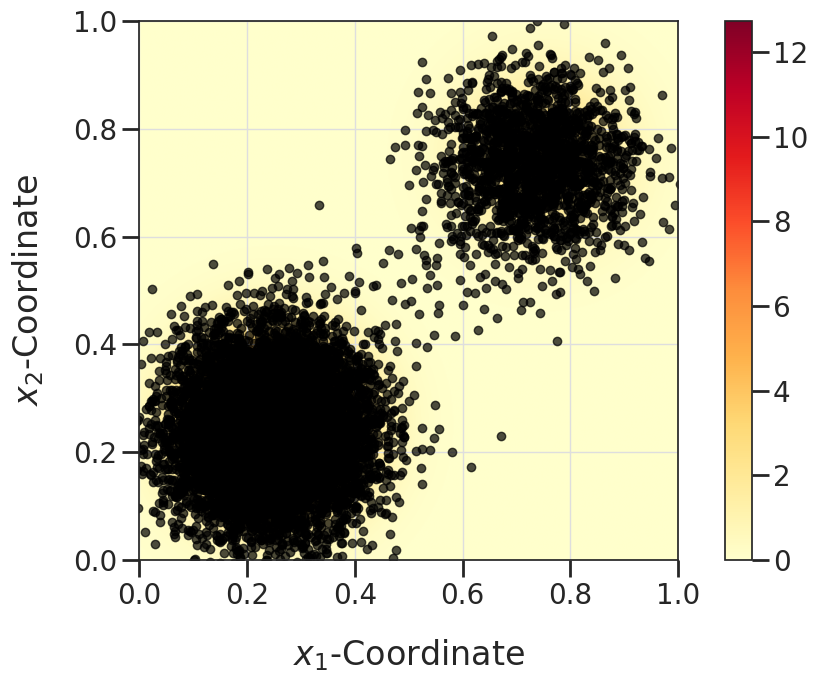

In [17]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy1_ddpm_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.sample((10000,), show_path=True)
    samples_all = samples_all.detach().cpu().numpy()

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
    origin='lower', cmap='YlOrRd'
)

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

**Accelerating Inference**

In [56]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

n_timesteps = 100
embedding_size = 24
model = DiffusionEpsilonParamImplicit(
    GaussianBase((x_sample_size,)),
    ConstantLinearScheduleImplicit(n_timesteps),
    MLPTimeDependent(
        n_timesteps, embedding_size,
        x_sample_size, x_sample_size, [64]*4,
        mlp_act_funs=[nn.GELU]*4 + [None],
        film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

/home/alzub/tmp/ipykernel_3576872/2627879652.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


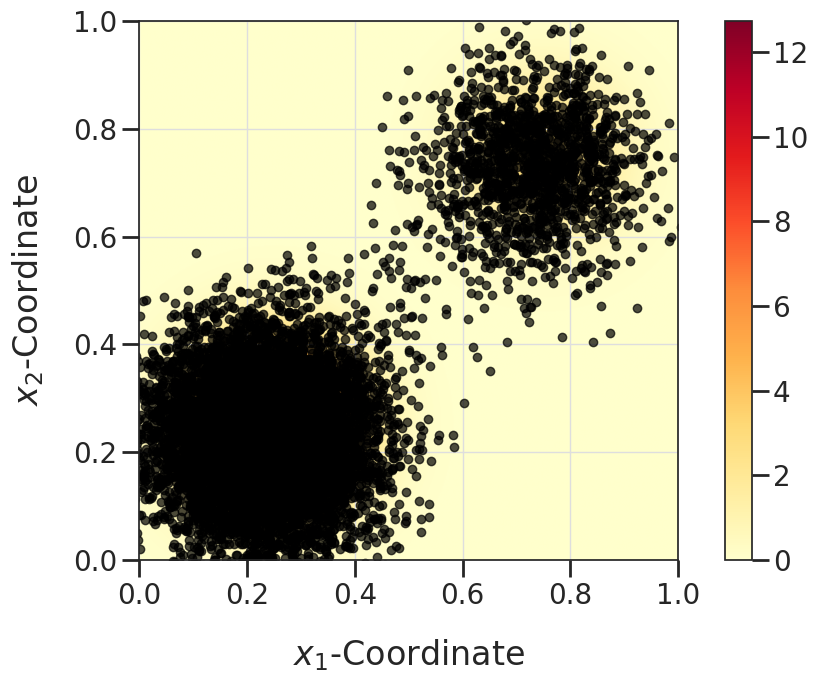

In [61]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy1_ddpm_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.sample(
        (10000,), n_steps=15, start_time=1, spacing="logsnr", show_path=True
    )
    samples_all = samples_all.detach().cpu().numpy()

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
    origin='lower', cmap='YlOrRd'
)

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

### 2.1.2 VDM on TwoGaussians

In [62]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

n_timesteps = 100
embedding_size = 24
gamma_hidden = 256
model = DiffusionEpsilonParam(
    GaussianBase((x_sample_size,)),
    LearnableLinearSchedule(
        n_timesteps, LinearMonotonicNetwork(1, gamma_hidden),
        gamma_limits=(-0.1, 0.1)
    ),
    MLPTimeDependent(
        n_timesteps, embedding_size,
        x_sample_size, x_sample_size, [64]*4,
        mlp_act_funs=[nn.GELU]*4 + [None],
        film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [63]:
epochs = 3
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for x in train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        loss = model(x, start_time=1)

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy1_vdm_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
)

Training: 100%|█████████▉| 2999/3000 [02:56<00:00, 20.21it/s, epoch=3/3, loss=⠀      0.0045]

In [64]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, loss=⠀      0.0045]           

/home/alzub/tmp/ipykernel_3576872/2345707616.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


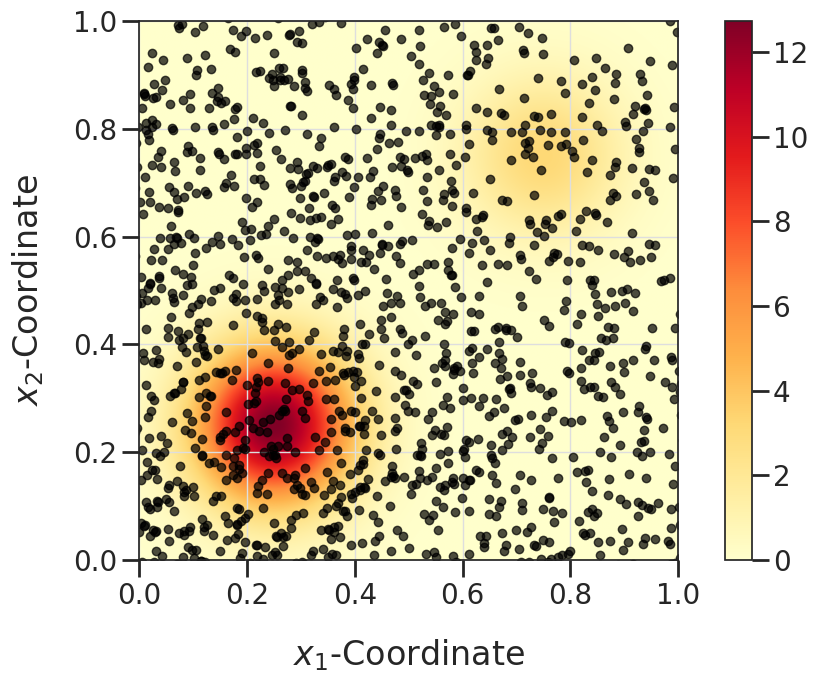

Training:   0%|          | 0/3000 [00:17<?, ?it/s, epoch=3/3, loss=⠀      0.0045]

In [65]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy1_vdm_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.sample((10000,), start_time=1, show_path=True)
    samples_all = samples_all.detach().cpu().numpy()

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
    origin='lower', cmap='YlOrRd'
)

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

## 2.2 Chequerboard

In [66]:
# Generate the data
n_data = 10000000
toy = Chequerboard(bounds=[-2, 2])
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 2.2.1 DDPM on Chequerboard

In [64]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

n_timesteps = 100
embedding_size = 24
model = DiffusionEpsilonParam(
    GaussianBase((x_sample_size,)),
    ConstantLinearSchedule(n_timesteps),
    MLPTimeDependent(
        n_timesteps, embedding_size,
        x_sample_size, x_sample_size, [64]*4,
        mlp_act_funs=[nn.GELU]*4 + [None],
        film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [ ]:
epochs = 3
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for x in train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        loss = model(x)

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy2_ddpm_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
)

Training:   0%|          | 0/3000 [00:27<?, ?it/s, epoch=3/3, loss=⠀      5.0216]


In [70]:
progress_bar.reset()

/home/alzub/tmp/ipykernel_2481107/1516391477.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


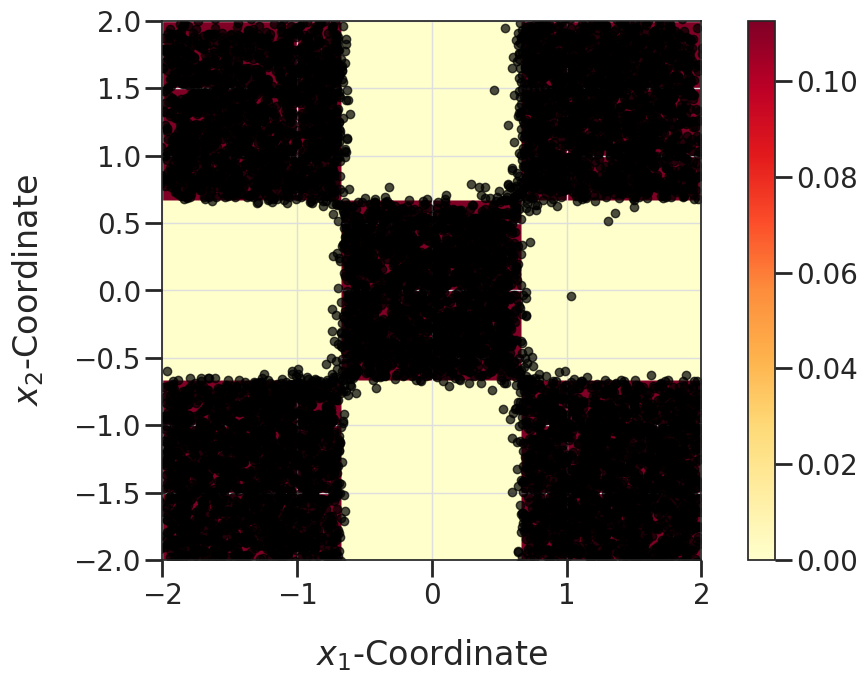

In [65]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy2_ddpm_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.sample((10000,), show_path=True)
    samples_all = samples_all.detach().cpu().numpy()

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
    origin='lower', cmap='YlOrRd'
)

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

**Accelerating Inference**

In [67]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

n_timesteps = 100
embedding_size = 24
model = DiffusionEpsilonParamImplicit(
    GaussianBase((x_sample_size,)),
    ConstantLinearScheduleImplicit(n_timesteps),
    MLPTimeDependent(
        n_timesteps, embedding_size,
        x_sample_size, x_sample_size, [64]*4,
        mlp_act_funs=[nn.GELU]*4 + [None],
        film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

/home/alzub/tmp/ipykernel_3576872/3470304587.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


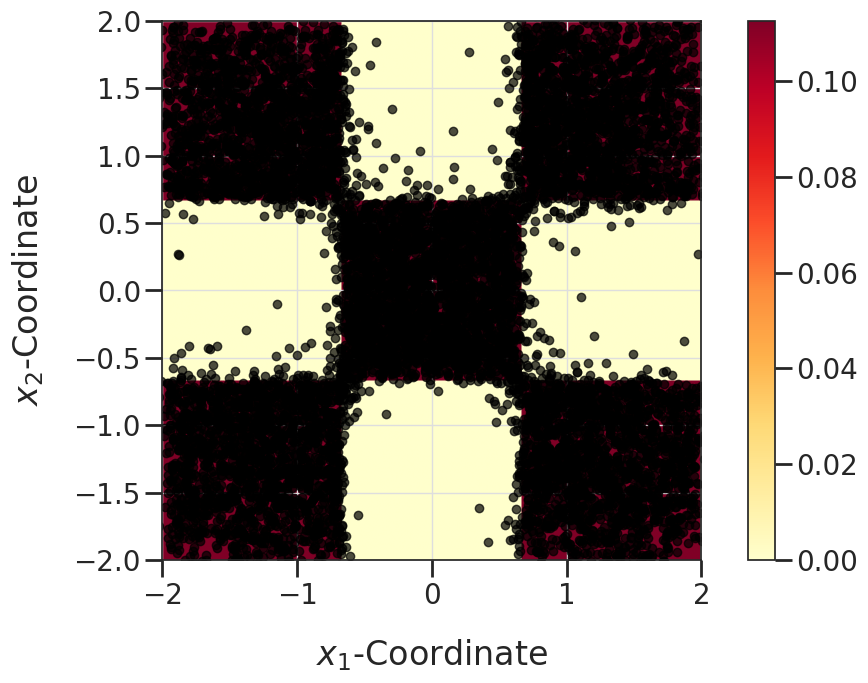

In [72]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy2_ddpm_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.sample(
        (10000,), n_steps=15, start_time=1, spacing="logsnr", show_path=True
    )
    samples_all = samples_all.detach().cpu().numpy()

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
    origin='lower', cmap='YlOrRd'
)

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

### 2.2.1 VDM on Chequerboard

In [72]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)

n_timesteps = 100
embedding_size = 24
gamma_hidden = 256
model = DiffusionEpsilonParam(
    GaussianBase((x_sample_size,)),
    LearnableLinearSchedule(
        n_timesteps, LinearMonotonicNetwork(1, gamma_hidden)),
    MLPTimeDependent(
        n_timesteps, embedding_size,
        x_sample_size, x_sample_size, [64]*4,
        mlp_act_funs=[nn.GELU]*4 + [None],
        film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [73]:
epochs = 3
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for x in train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        loss = model(x, start_time=1)

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy2_vdm_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
)

Training:   0%|          | 0/3000 [00:12<?, ?it/s, epoch=3/3, loss=⠀     34.0419]


Training: 100%|██████████| 3000/3000 [02:19<00:00, 20.80it/s, epoch=3/3, loss=⠀      6.3310]

In [74]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s, epoch=3/3, loss=⠀      6.3310]           

/home/alzub/tmp/ipykernel_93139/165727838.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


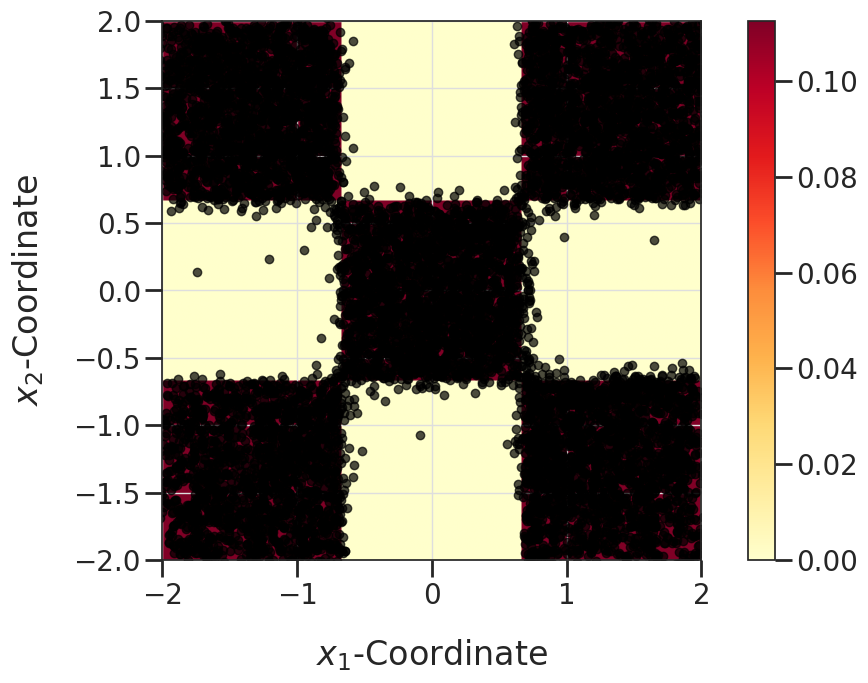

Training:   0%|          | 0/3000 [00:15<?, ?it/s, epoch=3/3, loss=⠀      6.3310]

In [75]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy2_vdm_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.sample((10000,), show_path=True)
    samples_all = samples_all.detach().cpu().numpy()

coordinates = [
    [[x,y] for x in np.linspace(*toy.xlim, 1000)]
    for y in np.linspace(*toy.ylim, 1000)
]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]],
    origin='lower', cmap='YlOrRd'
)

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

# 3. DMs on Easy, Real Data

## 3.1 MNIST

### 3.1.1 DDPM on MNIST

In [64]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()

n_timesteps = 1000
time_embedding_size = 128
class_embedding_size = 128
n_classes = 10
model = DiffusionEpsilonParam(
    GaussianBase((n_channels, height, width)),
    ConstantLinearSchedule(n_timesteps),
    UNetTimeClassDependent(
        # FiLM pars
        n_timesteps, time_embedding_size, class_embedding_size, n_classes,
        # CNN pars
        height, n_channels, [32, 64, 128, 256, 256],
        # convolution
        [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
        # pooling
        [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
        # transpose convolution
        [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
        unet_act_fun=nn.LogSigmoid, film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [ ]:
epochs = 100
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

total_steps = len(mnist_train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for x, y in mnist_train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        loss = model(x, y=y)

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"mnist_ddpm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
)

Training: 100%|█████████▉| 23499/23500 [23:40<00:00, 16.66it/s, epoch=100/100, loss=⠀      9.8743]

Training: 100%|██████████| 23500/23500 [23:51<00:00, 16.66it/s, epoch=100/100, loss=⠀      9.8743]

In [147]:
progress_bar.reset()

**Conditionally Trained Model**

In [65]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_ddpm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.sample((10,), y=y, show_path=False).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    samples = samples/2 + 0.5
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_ddpm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_2465028/2612297570.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Accelerating Inference**

In [78]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()

n_timesteps = 1000
time_embedding_size = 128
class_embedding_size = 128
n_classes = 10
model = DiffusionEpsilonParamImplicit(
    GaussianBase((n_channels, height, width)),
    ConstantLinearScheduleImplicit(n_timesteps),
    UNetTimeClassDependent(
        # FiLM pars
        n_timesteps, time_embedding_size, class_embedding_size, n_classes,
        # CNN pars
        height, n_channels, [32, 64, 128, 256, 256],
        # convolution
        [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
        # pooling
        [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
        # transpose convolution
        [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
        unet_act_fun=nn.LogSigmoid, film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [85]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_ddpm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
nt_sampling = 50
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.sample(
            (10,), n_steps=nt_sampling, start_time=1, y=y, show_path=False
        ).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    samples = samples/2 + 0.5
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_ddpm_conditional_{epochs}_n_epochs_{nt_sampling}_n_t_acc.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_3576872/414314743.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


### 3.1.2 VDM on MNIST

In [76]:
x_sample = next(iter(mnist_train_loader))[0][:1]
_, n_channels, height, width  = x_sample.size()

n_timesteps = 1000
time_embedding_size = 128
class_embedding_size = 128
gamma_hidden = 1024
n_classes = 10
model = DiffusionEpsilonParam(
    GaussianBase((n_channels, height, width)),
    LearnableLinearSchedule(
        n_timesteps, LinearMonotonicNetwork(1, gamma_hidden)),
    UNetTimeClassDependent(
        # FiLM pars
        n_timesteps, time_embedding_size, class_embedding_size, n_classes,
        # CNN pars
        height, n_channels, [32, 64, 128, 256, 256],
        # convolution
        [3, 3, 3, 3, 3], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1],
        # pooling
        [2, 2, 2, 2, 0], [2, 2, 2, 2, 1], [0, 0, 1, 0, 0],
        # transpose convolution
        [3, 3, 3, 3, 3], [2, 2, 2, 2, 1], [1, 1, 1, 1, 1], [1, 0, 1, 1, 0],
        unet_act_fun=nn.LogSigmoid, film_act_fun=nn.GELU
    ),
    n_timesteps
).to(DEVICE)

In [ ]:
epochs = 100
loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()

total_steps = len(mnist_train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")
for epoch in range(epochs):
    for x, y in mnist_train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        loss = model(x, y=y, start_time=1)

        loss.backward()
        optimizer.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"mnist_vdm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt"
)

Training:   0%|          | 0/3000 [00:32<?, ?it/s, epoch=3/3, loss=⠀      6.3310]


In [79]:
progress_bar.reset()

**Conditionally Trained Model**

In [80]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_vdm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.sample((10,), y=y, show_path=False).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    samples = samples/2 + 0.5
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_vdm_conditional_{epochs}_n_epochs_{n_timesteps}_n_t.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_93139/600819794.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
